In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
from dataclasses import dataclass, field

ftsz=12
plt.rcParams['figure.figsize'] = [5, 4]
plt.rc('font', family='serif')
plt.rc('xtick', labelsize=ftsz)
plt.rc('ytick', labelsize=ftsz)

In [87]:
def dislocation_stress(x, y, θ_j, s, μ=26.0e3, b=2.86e-4, ν=0.345):

    C   = μ * b / (4 * np.pi * (1 - ν))
    r2  = x**2 + y**2 + b**2
    d   = (x**2 - y**2)**2 + 4 * x**2 * y**2 + b**2

    RePhi_d   =  C * (x*np.sin(θ_j) - y*np.cos(θ_j)) / r2
    RePsi_d   =  C * (x*np.sin(θ_j) + y*np.cos(θ_j)) / r2
    RezPhi_dd = -C * ((x**2 - y**2)*(x*np.sin(θ_j) - y*np.cos(θ_j)) - 2*x*y*(x*np.cos(θ_j) + y*np.sin(θ_j))) / d
    ImPsi_d   =  C * (x*np.cos(θ_j) - y*np.sin(θ_j)) / r2
    ImzPhi_dd =  C * ((x**2 - y**2)*(x*np.cos(θ_j) + y*np.sin(θ_j)) + 2*x*y*(x*np.sin(θ_j) - y*np.cos(θ_j))) / d

    σxx = s * 0.5 * (4*RePhi_d - 2*(RezPhi_dd + RePsi_d))
    σyy = s * 0.5 * (4*RePhi_d + 2*(RezPhi_dd + RePsi_d))
    σxy = s * (ImzPhi_dd + ImPsi_d)

    return np.array([σxx, σyy, σxy])

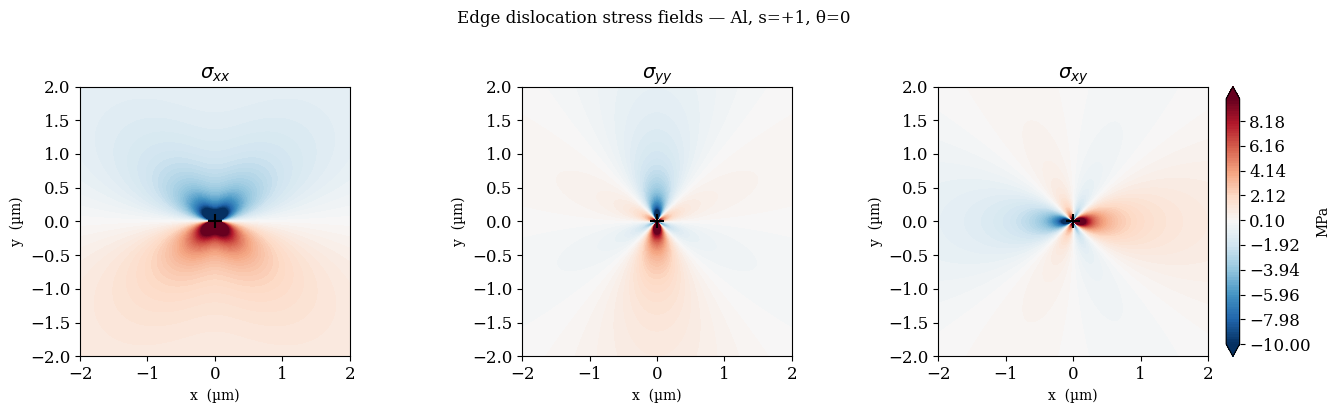

In [88]:
L    = 2
N    = 401
vmin, vmax = -10, 10   # MPa

lin  = np.linspace(-L, L, N)
X, Y = np.meshgrid(lin, lin)
σ = dislocation_stress(X, Y, 0, 1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
titles = [r'$\sigma_{xx}$', r'$\sigma_{yy}$', r'$\sigma_{xy}$']
fields = [σ[0], σ[1], σ[2]]

for ax, field, title in zip(axes, fields, titles):
    cf = ax.contourf(X, Y, field,
                     levels=np.linspace(vmin, vmax, 100),
                     cmap='RdBu_r', vmin=vmin, vmax=vmax,
                     extend='both')
    #fig.colorbar(cf, ax=ax, label='MPa')
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('x  (µm)')
    ax.set_ylabel('y  (µm)')
    ax.set_aspect('equal')
    ax.plot(0, 0, 'k+', markersize=10, markeredgewidth=1.5)

fig.colorbar(cf, ax=axes[-1], label='MPa')

plt.suptitle('Edge dislocation stress fields — Al, s=+1, θ=0', y=1.02)
plt.tight_layout()
plt.show()

In [172]:
@dataclass
class Dislocations:
    x:          np.ndarray  # float64
    y:          np.ndarray  # float64
    sign:       np.ndarray  # int8, values +1 or -1
    slip_plane: np.ndarray  # int32
    is_pinned:  np.ndarray  # bool

    def __len__(self):
        return len(self.x)
        
    def add(self, x, y, sign, slip_plane, is_pinned):
        self.x          = np.append(self.x,          x)
        self.y          = np.append(self.y,          y)
        self.sign       = np.append(self.sign,       sign)
        self.slip_plane = np.append(self.slip_plane, slip_plane)
        self.is_pinned  = np.append(self.is_pinned,  is_pinned)

    def copy(self):
        return Dislocations(
            x          = self.x.copy(),
            y          = self.y.copy(),
            sign       = self.sign.copy(),
            slip_plane = self.slip_plane.copy(),
            is_pinned  = self.is_pinned.copy(),
        )        

In [326]:
N = 0
disl = Dislocations(
    x          = np.zeros(N,  dtype=np.float64),
    y          = np.zeros(N,  dtype=np.float64),
    sign       = np.ones(N,   dtype=np.int8),
    slip_plane = np.zeros(N,  dtype=np.int32),
    is_pinned = np.zeros(N,  dtype=np.bool),
)

SP = SlipPlane(
    θ          = np.zeros(N,  dtype=np.float64),
    n          = np.zeros(N,  dtype=np.int32), 
)

disl.add(x=1.0, y=0.0, sign=1, slip_plane=0, is_pinned=False)
disl.add(x= -1.0, y=0.0, sign=-1, slip_plane=1, is_pinned=False)

θ_SP = np.array([0, np.pi/2])

In [221]:
def get_stress_at_disl(i, σ_ext, disl, θ_SP, μ=26.0e3, b=2.86e-4, ν=0.345):
    # 
    σ = σ_ext.copy().astype(float)       # initialise to external stress without modifying σ_ext
    for j in range(len(disl)):
        if j != i:        # avoid stress from this dislocation
            σ += dislocation_stress(disl.x[i] - disl.x[j], disl.y[i] - disl.y[j], θ_SP[disl.slip_plane[j]], disl.sign[j])
    return σ


def get_stress_at_point(x, y, σ_ext, disl, θ_SP, μ=26.0e3, b=2.86e-4, ν=0.345):
    # 
    σ = σ_ext.copy().astype(float)      # initialise to external stress without modifying σ_ext
    for j in range(len(disl)):
        σ += dislocation_stress(x - disl.x[j], y - disl.y[j], θ_SP[disl.slip_plane[j]], disl.sign[j])
    return σ

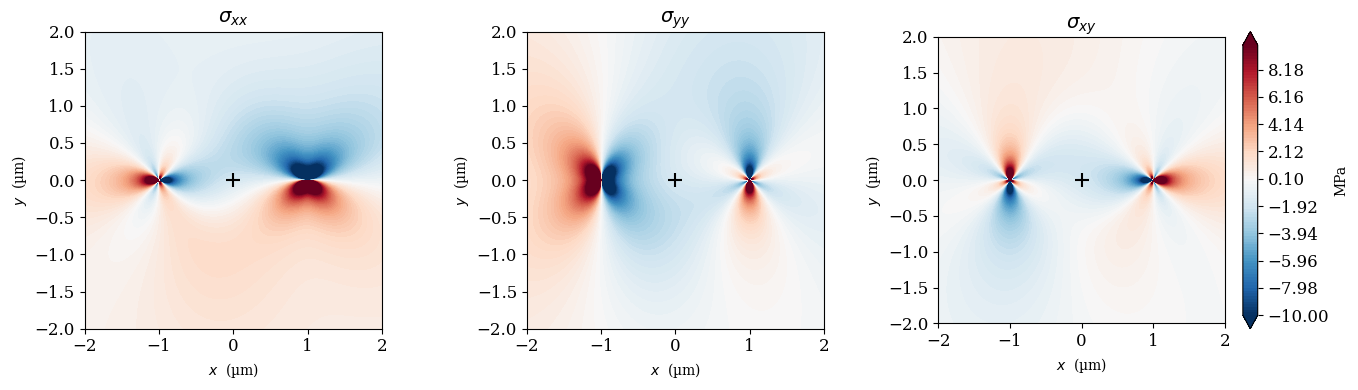

In [247]:
L    = 2
N    = 401
vmin, vmax = -10, 10   # MPa

lin  = np.linspace(-L, L, N)
X, Y = np.meshgrid(lin, lin)
σ = dislocation_stress(X-1, Y, 0, 1)
σ = σ + dislocation_stress(X+1, Y, np.pi/2, -1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
titles = [r'$\sigma_{xx}$', r'$\sigma_{yy}$', r'$\sigma_{xy}$']
fields = [σ[0], σ[1], σ[2]]

for ax, field, title in zip(axes, fields, titles):
    cf = ax.contourf(X, Y, field,
                     levels=np.linspace(vmin, vmax, 100),
                     cmap='RdBu_r', vmin=vmin, vmax=vmax,
                     extend='both')
    #fig.colorbar(cf, ax=ax, label='MPa')
    ax.set_title(title, fontsize=14)
    ax.set_xlabel(r'$x$  (µm)')
    ax.set_ylabel(r'$y$  (µm)')
    ax.set_aspect('equal')
    ax.plot(0, 0, 'k+', markersize=10, markeredgewidth=1.5)

fig.colorbar(cf, ax=axes[-1], label='MPa')

#plt.suptitle('Edge dislocation stress fields — Al, s=+1, θ=0', y=1.02)
plt.tight_layout()
plt.show()

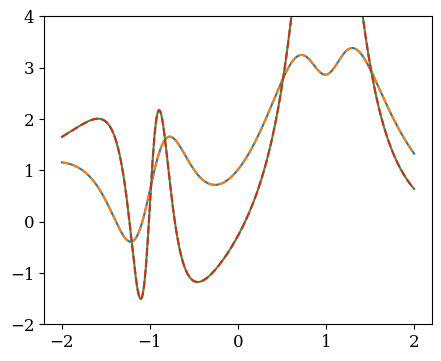

In [327]:
σ_ext = np.zeros(3)
σ_scan1 = np.array([get_stress_at_point(x, Y[150][0], σ_ext, disl, θ_SP)[0] for x in X[150]])
σ_scan2 = np.array([get_stress_at_point(x, Y[175][0], σ_ext, disl, θ_SP)[0] for x in X[175]])

plt.plot(X[150], fields[0][150])
plt.plot(X[150], σ_scan1, '--')
plt.plot(X[175], fields[0][175])
plt.plot(X[150], σ_scan2, '--')
plt.ylim(-2, 4)
plt.show()

In [229]:
def update_dislocations(disl, σ_ext, θ_SP, B=1e-4, dt=1e-6, v_cutoff=1e3, μ=26.0e3, b=2.86e-4, ν=0.345):
    # 
    new_config = disl.copy()      # initialise to external stress without modifying σ_ext

    for j in range(len(disl)):
        if disl.is_pinned[j] == False:
            # get stress at the dislocation
            σ = get_stress_at_disl(j, σ_ext, disl, θ_SP)
            # calculate the PK force expanding n*σ*b
            F = disl.sign[j]*b*((σ[1]-σ[0])*np.sin(θ_SP[disl.slip_plane[j]])*np.cos(θ_SP[disl.slip_plane[j]])+σ[2]*np.cos(2*θ_SP[disl.slip_plane[j]]));

            # Calculate the velocity as F/B and update the position as x = x_old + v*dt
            v = np.clip(F/B, -v_cutoff, v_cutoff) # shorthand for capping speed to +/- the cutoff but keeping the sign

            new_config.x[j] += v*np.cos(θ_SP[disl.slip_plane[j]])*dt;
            new_config.y[j] += v*np.sin(θ_SP[disl.slip_plane[j]])*dt;

            # check if an obstacle has been passed
    
    return new_config

In [304]:
def evolve_dislocations(disl, σ_ext, θ_SP, t_end, plot_every = 100, B=1e-4, dt=1e-6, v_cutoff=1e4, μ=26.0e3, b=2.86e-4, ν=0.345):

    # iteratively step from t = 0 to t = t_end by checking for nucleation and updating the dislocation positions under stress
    for t in range(int(t_end/dt)):
        # update the positions of existing dislocations
        disl = update_dislocations(disl, σ_ext, θ_SP)
        if t % plot_every == 0:
            clear_output(wait=True)
            plot_stress_disl(disl, θ_SP)
    return disl

In [318]:
from IPython.display import clear_output
def plot_stress_disl(disl, θ_SP, L=.2, N=201, vmin=-100, vmax=100):
    lin  = np.linspace(-L, L, num=N)
    X, Y = np.meshgrid(lin, lin)
    # sum stress from all dislocations
    σ = np.zeros((3, N, N))
    for j in range(len(disl)):
        σ += dislocation_stress(X - disl.x[j], Y - disl.y[j], θ_SP[disl.slip_plane[j]], disl.sign[j])
    #σ += σ_ext[:, None, None]  # add external stress if nonzero
    
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    titles = [r'$\sigma_{xx}$', r'$\sigma_{yy}$', r'$\sigma_{xy}$']
    for ax, field, title in zip(axes, [σ[0], σ[1], σ[2]], titles):
        cf = ax.contourf(X, Y, field,
                         levels=np.linspace(vmin, vmax, 100),
                         cmap='RdBu_r', vmin=vmin, vmax=vmax,
                         extend='both')
        ax.set_title(title, fontsize=14)
        ax.set_xlabel(r'$x$  (µm)')
        ax.set_ylabel(r'$y$  (µm)')
        ax.set_aspect('equal')
        ax.set_xlim(-L, L)
        ax.set_ylim(-L, L)
        # plot dislocation positions
        for j in range(len(disl)):
            marker = '+' if disl.sign[j] == 1 else '_'
            ax.plot(disl.x[j], disl.y[j], 'k', marker=marker, markersize=10, markeredgewidth=1.5)
    cb = fig.colorbar(cf, ax=axes[-1])
    cb.set_label('MPa', rotation=0, labelpad=10, loc='top')
    plt.tight_layout()
    plt.show()

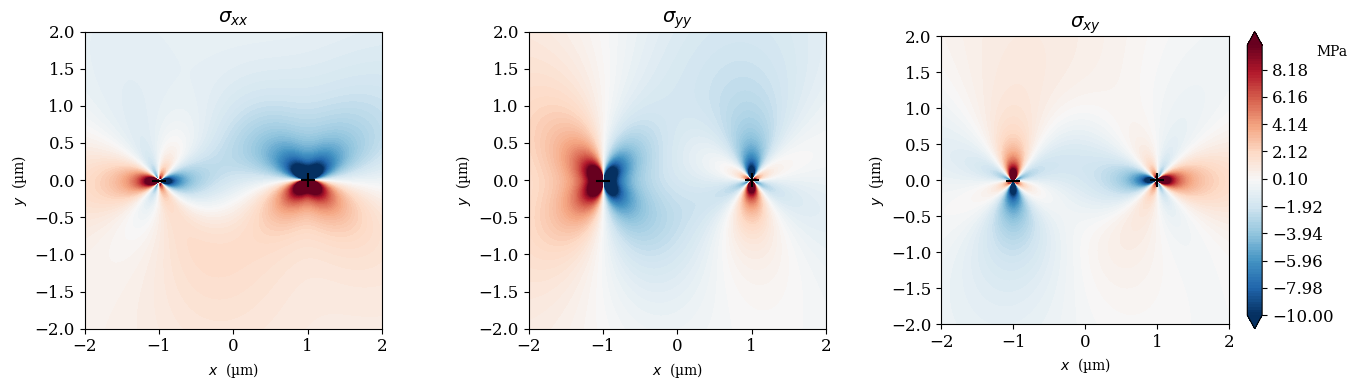

In [306]:
_ = evolve_dislocations(disl, np.array([0, 0, 0.0]), θ_SP, 5000e-6)

In [162]:
# two dislocations on parallel slip planes finding a stable config

In [332]:
N = 0
disl = Dislocations(
    x          = np.zeros(N,  dtype=np.float64),
    y          = np.zeros(N,  dtype=np.float64),
    sign       = np.ones(N,   dtype=np.int8),
    slip_plane = np.zeros(N,  dtype=np.int32),
    is_pinned = np.zeros(N,  dtype=np.bool),
)

disl.add(x=0.05, y=0.1, sign=1, slip_plane=0, is_pinned=False)
disl.add(x= -0.1, y=-0.1, sign=-1, slip_plane=1, is_pinned=False)

θ_SP = np.array([0, 0])

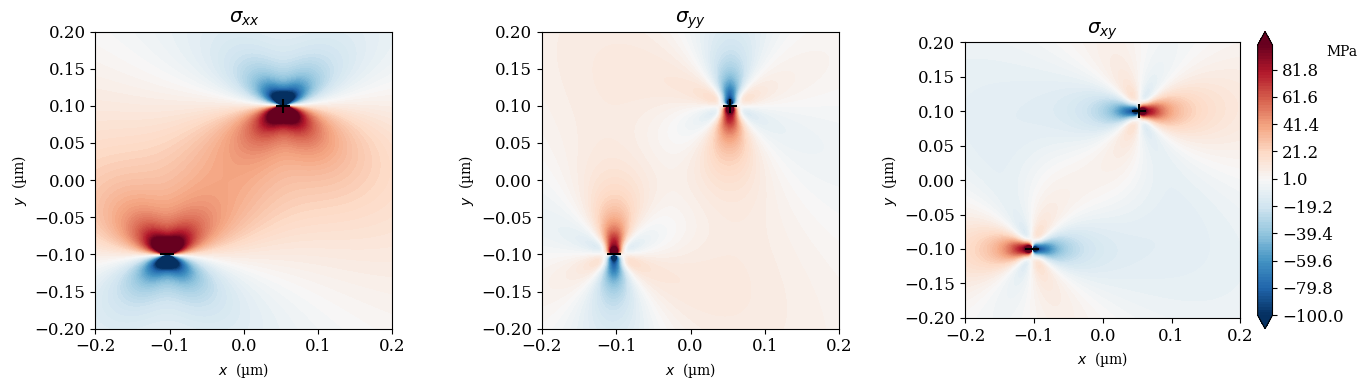

In [333]:
_ = evolve_dislocations(disl, np.array([0, 0, 0.0]), θ_SP, 1e-3)

In [334]:
get_stress_at_disl(0, np.array([0, 0, 0.0]), disl, θ_SP)

array([9.9447754 , 1.61894596, 1.21412434])

In [335]:
get_stress_at_disl(1, np.array([0, 0, 0.0]), disl, θ_SP)

array([9.9447754 , 1.61894596, 1.21412434])